# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


# Load Dataset

In [54]:
df = pd.read_csv("C:\\Users\\ASUS\\Downloads\\Hotel_bookings_final.csv.csv")

# Preview
df.head()

,customer_id,property_id,city,star_rating,booking_date,check_in_date,check_out_date,room_type,num_rooms_booked,stay_type,...,selling_price,payment_method,refund_status,refund_amount,channel_of_booking,booking_status,travel_date,cashback,coupon_redeem,Coupon USed?
0,492,3,San Francisco,4,2024-04-01,2024-05-24,2024-05-26,Standard,1,Leisure,...,25342,PayPal,Yes,369.648995,Web,Confirmed,2024-03-04,5.374694,0.000000,No
1,180,3,Dallas,3,2024-04-01,2024-05-10,2024-05-17,Deluxe,1,Leisure,...,8033,Bank Transfer,Yes,492.505903,Web,Confirmed,2024-07-19,7.161033,0.000000,No
2,50,5,Dallas,3,2024-04-01,2024-05-31,2024-06-05,Deluxe,1,Business,...,29715,Debit Card,Yes,0.000000,iOS,Confirmed,2024-03-22,0.000000,0.000000,No
3,294,3,Orlando,4,2024-04-01,2024-04-18,2024-04-24,Deluxe,3,Leisure,...,44592,Bank Transfer,Yes,545.541516,Android,Confirmed,2024-11-24,7.932170,24.500442,Yes
4,40,5,Seattle,5,2024-04-01,NaN,NaN,Deluxe,1,Leisure,...,15873,Debit Card,Yes,211.367602,Web,Cancelled,2024-03-02,0.000000,0.000000,No


# Data Understanding

In [9]:
# Shape
print("Shape:", df.shape)

# Info
df.info()

# Summary statistics
df.describe()

Shape: (30000, 24)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         30000 non-null  int64  
 1   property_id         30000 non-null  int64  
 2   city                30000 non-null  object 
 3   star_rating         30000 non-null  int64  
 4   booking_date        30000 non-null  object 
 5   check_in_date       24532 non-null  object 
 6   check_out_date      24532 non-null  object 
 7   room_type           30000 non-null  object 
 8   num_rooms_booked    30000 non-null  int64  
 9   stay_type           30000 non-null  object 
 10  booking_channel     30000 non-null  object 
 11  booking_value       30000 non-null  float64
 12  costprice           30000 non-null  int64  
 13  markup              30000 non-null  int64  
 14  selling_price       30000 non-null  int64  
 15  payment_method      30000 non-null

,customer_id,property_id,star_rating,num_rooms_booked,booking_value,costprice,markup,selling_price,refund_amount,cashback,coupon_redeem
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,249.721767,3.777533,3.602033,1.352333,25080.525454,22541.494100,6963.32440,29504.818500,320.938376,3.831534,4.134988
std,145.484836,2.081471,0.860241,0.574403,11587.369335,9259.520787,2860.10657,12119.627338,339.635396,4.783590,10.846221
min,1.000000,1.000000,2.000000,1.000000,1279.770000,3822.000000,1181.00000,5003.000000,0.000000,0.000000,-3.532183
25%,123.000000,1.000000,3.000000,1.000000,15922.712500,15088.750000,4661.75000,19750.500000,0.000000,0.000000,0.000000
50%,248.000000,3.000000,4.000000,1.000000,24736.145000,22731.000000,7021.50000,29752.500000,221.141185,1.030180,0.000000
75%,376.000000,5.000000,4.000000,2.000000,33570.000000,30427.000000,9399.00000,39826.000000,594.624344,7.378533,0.000000
max,499.000000,7.000000,5.000000,3.000000,67764.460000,38200.000000,11800.00000,50000.000000,1462.725105,21.268013,89.644917


# Data Preprocessing

In [11]:
# Convert date columns
df['booking_date'] = pd.to_datetime(df['booking_date'], errors='coerce')
df['travel_date'] = pd.to_datetime(df['travel_date'], errors='coerce')

# Create cancellation flag
df['is_cancelled'] = df['booking_status'].str.lower().str.contains('cancel').astype(int)

# Extract month
df['month'] = df['booking_date'].dt.month

# Check missing values
df.isnull().sum()

customer_id              0
property_id              0
city                     0
star_rating              0
booking_date             0
check_in_date         5468
check_out_date        5468
room_type                0
num_rooms_booked         0
stay_type                0
booking_channel          0
booking_value            0
costprice                0
markup                   0
selling_price            0
payment_method           0
refund_status            0
refund_amount            0
channel_of_booking       0
booking_status           0
travel_date              0
cashback                 0
coupon_redeem            0
Coupon USed?             0
is_cancelled             0
month                    0
dtype: int64

# Key Metrices

In [13]:
# Overall cancellation rate
cancel_rate = df['is_cancelled'].mean()
print("Overall Cancellation Rate:", round(cancel_rate*100,2), "%")

Overall Cancellation Rate: 20.23 %


# Analysis Booking Channel

In [15]:
channel_cancel = df.groupby('booking_channel')['is_cancelled'].mean().sort_values(ascending=False)
channel_cancel

booking_channel
Travel Agent    0.279264
Mobile App      0.215588
Web             0.176388
Name: is_cancelled, dtype: float64

# Visualization

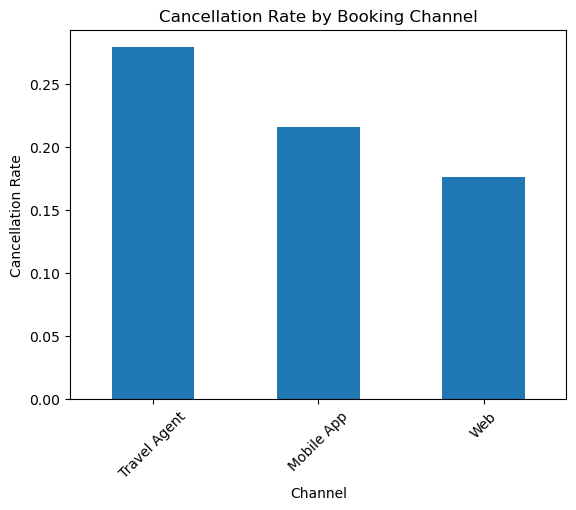

In [17]:
channel_cancel.plot(kind='bar')
plt.title("Cancellation Rate by Booking Channel")
plt.xlabel("Channel")
plt.ylabel("Cancellation Rate")
plt.xticks(rotation=45)
plt.show()

# Analysis Groub By

In [19]:
room_cancel = df.groupby('room_type')['is_cancelled'].mean().sort_values(ascending=False)
room_cancel

room_type
Standard    0.233023
Suite       0.179798
Deluxe      0.160241
Name: is_cancelled, dtype: float64

# Visualization

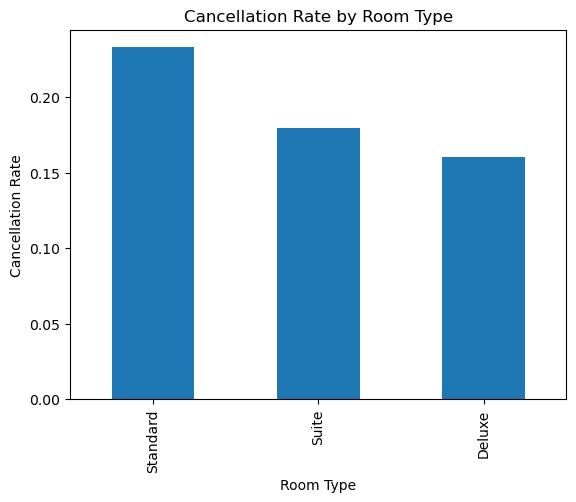

In [21]:
room_cancel.plot(kind='bar')
plt.title("Cancellation Rate by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Cancellation Rate")
plt.show()

# Analysis Star Rating

In [23]:
star_cancel = df.groupby('star_rating')['is_cancelled'].mean().sort_values()
star_cancel

star_rating
2    0.197663
4    0.199934
3    0.202008
5    0.212591
Name: is_cancelled, dtype: float64

# Visualization

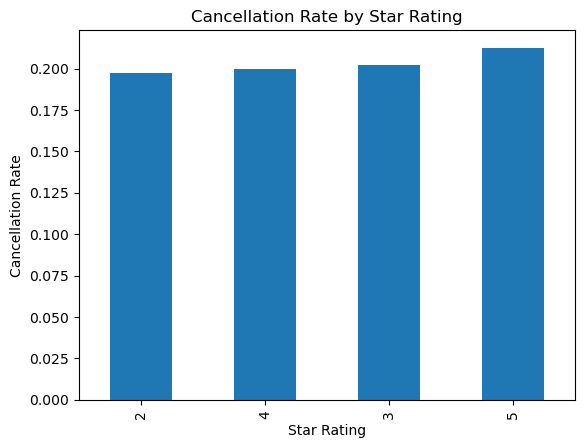

In [25]:
star_cancel.plot(kind='bar')
plt.title("Cancellation Rate by Star Rating")
plt.xlabel("Star Rating")
plt.ylabel("Cancellation Rate")
plt.show()

# Monthly Trend Analysis

In [27]:
monthly_booking_value = df.groupby('month')['booking_value'].mean()
monthly_booking_value

month
1     23424.240288
2     27806.446412
3     27316.317513
4     25116.494933
5     23197.152432
6     24202.785705
7     25501.593859
8     26064.735975
9     24635.105197
10    24880.617462
11    25753.245326
12    23276.987242
Name: booking_value, dtype: float64

# Visualization

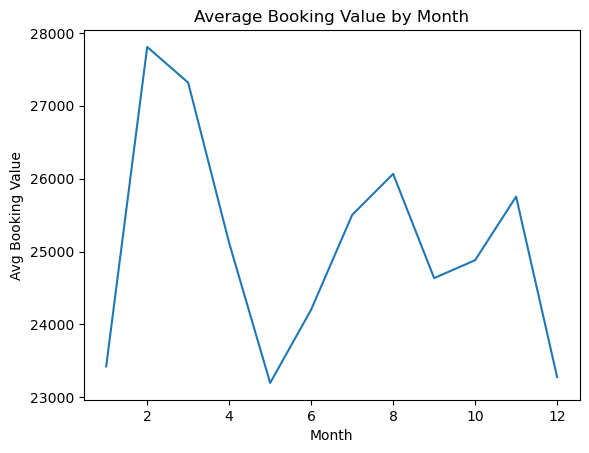

In [29]:
monthly_booking_value.plot()
plt.title("Average Booking Value by Month")
plt.xlabel("Month")
plt.ylabel("Avg Booking Value")
plt.show()

# Profit Analysis

In [31]:
# Profit calculation
df['profit'] = df['selling_price'] - df['costprice']

# Profit by channel
profit_channel = df.groupby('booking_channel')['profit'].mean()
profit_channel

booking_channel
Mobile App      6943.901074
Travel Agent    6931.740468
Web             6985.168989
Name: profit, dtype: float64

# Visualization

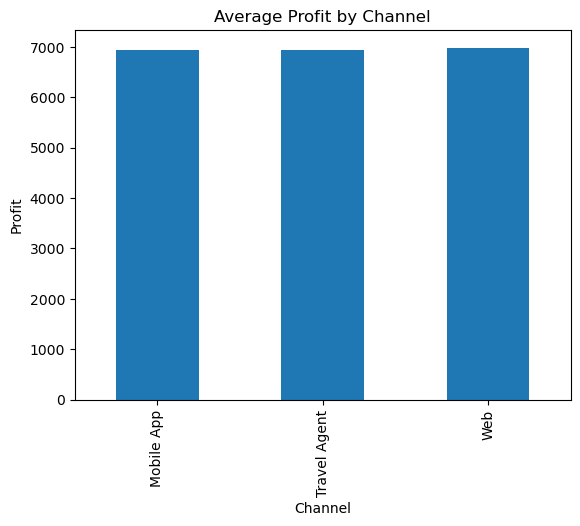

In [33]:
profit_channel.plot(kind='bar')
plt.title("Average Profit by Channel")
plt.xlabel("Channel")
plt.ylabel("Profit")
plt.show()

# Coupon & Cashback Impact

In [41]:
coupon_usage = df['Coupon USed?'].value_counts()
coupon_usage

Coupon USed?
No     23807
Yes     6193
Name: count, dtype: int64

In [43]:
df.groupby('Coupon USed?')['is_cancelled'].mean()

Coupon USed?
No     0.200865
Yes    0.207977
Name: is_cancelled, dtype: float64

# Stay Length Analysis

In [45]:
df['check_in_date'] = pd.to_datetime(df['check_in_date'], errors='coerce')
df['check_out_date'] = pd.to_datetime(df['check_out_date'], errors='coerce')

df['stay_length'] = (df['check_out_date'] - df['check_in_date']).dt.days

df[['stay_length', 'is_cancelled']].dropna().groupby('stay_length')['is_cancelled'].mean().head()

stay_length
1.0    0.036565
2.0    0.044924
3.0    0.046591
4.0    0.038693
5.0    0.040433
Name: is_cancelled, dtype: float64

# Key Insights Print

In [47]:
print("Top Cancellation Channel:", channel_cancel.idxmax())
print("Highest Cancellation Room Type:", room_cancel.idxmax())
print("Lowest Cancellation Channel:", channel_cancel.idxmin())

Top Cancellation Channel: Travel Agent
Highest Cancellation Room Type: Standard
Lowest Cancellation Channel: Web


# Correlation Heatmap

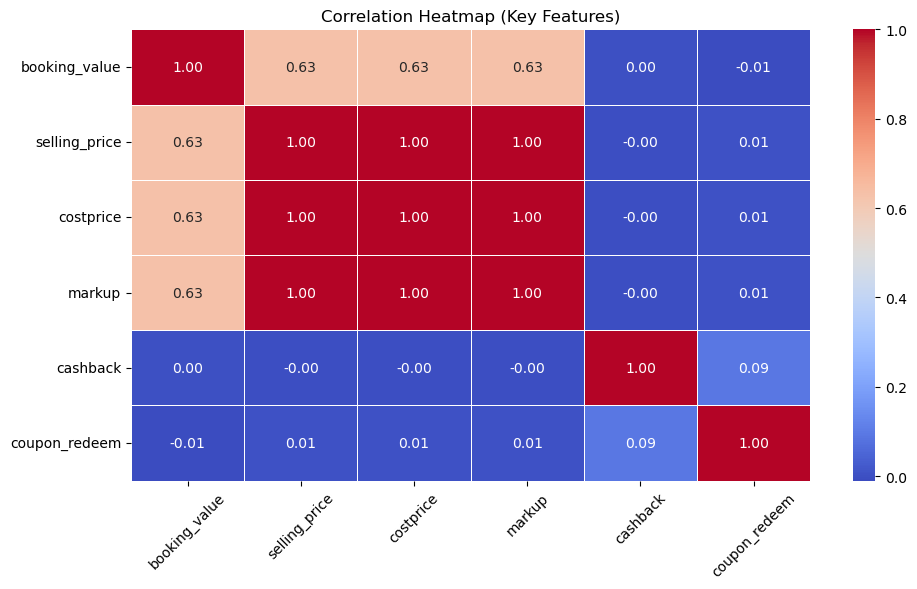

In [52]:
# Select only important numeric columns
important_cols = [
    'booking_value', 'selling_price', 'costprice',
    'markup', 'cashback', 'coupon_redeem'
]

# Plot heatmap
plt.figure(figsize=(10,6))

sns.heatmap(
    df[important_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Correlation Heatmap (Key Features)")
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()